# 18 - Embeddings v8: progression (edit-distance) embedding

Third axis of the music-theoretic decomposition: **progressions = order matters**.

Where v6 trajectory-space used orbit *sets* (Jaccard, order-free), v8 progression-space
uses orbit *sequences* over a finite alphabet (sector in Z/12, optionally joint
sector x mod3) compared with **Levenshtein edit distance**.

Edit distance is tempo-flexible (insertions/deletions handle different orbit lengths)
but progression-strict (substitutions cost — two progressions that diverge at step k
are penalized).

**Hypotheses:**

1. Progression-edit-distance should still recover Syracuse-shift well (one delete from
   the sequence head — small edit distance).
2. Tempo invariance: orbits of very different lengths are not trivially distance ~ 1
   if one is a suffix-aligned subsequence of the other.
3. Same-orbit-length integers have IDENTICAL sector progressions (it's just L mod 12,
   L-1 mod 12, ..., 0 — purely a function of L). The joint progression breaks this
   degeneracy.
4. On the v7 categories — tripling, set-mate — progression-distance probably won't
   beat the established methods, but the joint variant might.


In [1]:
import sys
sys.path.insert(0, '..')

import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import Concept, trajectory_analogy
from collatz.embeddings.distance import analogy as lens_analogy
from collatz.embeddings.iteration import _syr_step
from collatz.embeddings.progression import (
    sector_progression,
    joint_progression,
    edit_distance,
    normalized_edit_distance,
    progression_distance,
    concept_progression_distance,
    progression_analogy,
    nearest_progression,
)
from collatz.utils import members_of_class
from collatz.dropping import dropping_set
from collatz.core import alpha_sequence


## 1. Sanity / fixtures

Print sector and joint progressions for a few integers; verify by hand.


In [2]:
for n in [1, 3, 5, 7, 11, 17, 27]:
    L = len(alpha_sequence(n)) if n > 1 else 0
    print(f"n={n}  L={L}")
    print(f"  sector_progression: {sector_progression(n)}")
    print(f"  joint_progression : {joint_progression(n)}")


n=1  L=0
  sector_progression: (0,)
  joint_progression : ((0, 1),)
n=3  L=2
  sector_progression: (2, 1, 0)
  joint_progression : ((2, 0), (1, 2), (0, 1))
n=5  L=1
  sector_progression: (1, 0)
  joint_progression : ((1, 2), (0, 1))
n=7  L=5
  sector_progression: (5, 4, 3, 2, 1, 0)
  joint_progression : ((5, 1), (4, 2), (3, 2), (2, 1), (1, 2), (0, 1))
n=11  L=4
  sector_progression: (4, 3, 2, 1, 0)
  joint_progression : ((4, 2), (3, 2), (2, 1), (1, 2), (0, 1))
n=17  L=3
  sector_progression: (3, 2, 1, 0)
  joint_progression : ((3, 2), (2, 1), (1, 2), (0, 1))
n=27  L=41
  sector_progression: (5, 4, 3, 2, 1, 0, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0)
  joint_progression : ((5, 0), (4, 2), (3, 1), (2, 2), (1, 2), (0, 2), (11, 2), (10, 1), (9, 1), (8, 2), (7, 1), (6, 2), (5, 2), (4, 1), (3, 2), (2, 2), (1, 2), (0, 1), (11, 2), (10, 2), (9, 2), (8, 1), (7, 2), (6, 1), (5, 2), (4, 2), (3, 2), (2, 2), (1, 2), (0, 2), (1

**By hand for n=3:** alpha_sequence(3) = [1, 4], so L=2 Syracuse hops.
The orbit is 3 -> 5 -> 1. Sectors L mod 12, L-1 mod 12, ..., 0 = (2, 1, 0).
mod3 along the orbit: 3%3=0, 5%3=2, 1%3=1 -> joint = ((2,0), (1,2), (0,1)). ✓

**By hand for n=7:** alpha_sequence has length 5; orbit is 7 -> 11 -> 17 -> 13 -> 5 -> 1.
sectors (5,4,3,2,1,0); mod3 along orbit (1,2,2,1,2,1). ✓


In [3]:
# Edit distance smoke
print("edit_distance('abc', 'abc') =", edit_distance('abc', 'abc'))
print("edit_distance('abc', 'abd') =", edit_distance('abc', 'abd'))
print("edit_distance('abc', 'abcd') =", edit_distance('abc', 'abcd'))
print("edit_distance('kitten', 'sitting') =", edit_distance('kitten', 'sitting'))
print()
print("progression_distance(3, 3)  =", progression_distance(3, 3))
print("progression_distance(3, 5)  =", round(progression_distance(3, 5), 3))
print("progression_distance(7, 11) =", round(progression_distance(7, 11), 3),
      " <- 11 = T_syr(7), expect small (one delete)")


edit_distance('abc', 'abc') = 0
edit_distance('abc', 'abd') = 1
edit_distance('abc', 'abcd') = 1
edit_distance('kitten', 'sitting') = 3

progression_distance(3, 3)  = 0.0
progression_distance(3, 5)  = 0.333
progression_distance(7, 11) = 0.167  <- 11 = T_syr(7), expect small (one delete)


## 2. Re-run the v6 Syracuse-shift experiment

Same 30 quads from notebook 14 (v6). 100 distractors. Compare four methods:

- **v1 lens_analogy** (cosine on lens-bundle Phi)
- **v6 trajectory_analogy** (Jaccard distance on orbit sets)
- **v8 progression_analogy** (sector edit distance)
- **v8 progression_analogy joint=True** (sector x mod3 edit distance)

Report mean rank, top-5, top-10 per method.


In [4]:
def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

random.seed(42)  # same seed as nb 14 (v6) big_quads
big_quads = []
for i in range(30):
    scale = random.choice([20, 100, 500, 2000])
    a_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))  # odd
    c_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    a = Concept(f"A{i}", a_start)
    b = shift(a)
    c = Concept(f"C{i}", c_start)
    d = shift(c)
    big_quads.append((a, b, c, d))

big_distractors = [
    Concept(f"D{i}", tuple(random.randrange(2, 5000) for _ in range(3)))
    for i in range(100)
]

print(f"Built {len(big_quads)} Syracuse-shift quads, {len(big_distractors)} distractors.")


Built 30 Syracuse-shift quads, 100 distractors.


In [5]:
def rank_with(method, quads, distractors, **kwargs):
    ranks = []
    for a, b, c, expected_d in quads:
        pool = distractors + [expected_d]
        ranked = method(a, b, c, pool, **kwargs) if kwargs else method(a, b, c, pool)
        rank = next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)
        ranks.append(rank)
    return np.array(ranks)


methods = [
    ("v1 lens-Phi cosine",       lambda a, b, c, p: lens_analogy(a, b, c, p)),
    ("v6 trajectory_analogy",    lambda a, b, c, p: trajectory_analogy(a, b, c, p)),
    ("v8 progression (sector)",  lambda a, b, c, p: progression_analogy(a, b, c, p, joint=False)),
    ("v8 progression (joint)",   lambda a, b, c, p: progression_analogy(a, b, c, p, joint=True)),
]

results_syr = {}
for name, fn in methods:
    results_syr[name] = rank_with(fn, big_quads, big_distractors)

pool_size = len(big_distractors) + 1
chance = pool_size / 2

print(f"Pool size: {pool_size}, chance baseline: {chance:.0f}")
print(f"{'method':<28} {'mean':>7} {'median':>8} {'top-5':>6} {'top-10':>7}")
print('-' * 60)
for name, ranks in results_syr.items():
    print(f"{name:<28} {ranks.mean():>7.1f} {np.median(ranks):>8.0f} "
          f"{(ranks < 5).sum():>6} {(ranks < 10).sum():>7}")


Pool size: 101, chance baseline: 50
method                          mean   median  top-5  top-10
------------------------------------------------------------
v1 lens-Phi cosine              37.0       33      5       9
v6 trajectory_analogy            0.2        0     30      30
v8 progression (sector)          1.2        0     28      29
v8 progression (joint)           0.3        0     29      30


**Read the table.** v6 perfect by construction (orbit(d) is a suffix of orbit(c));
expect v8 sector and joint to be close behind, since the sector progression of d
is also a tail-aligned subsequence of c's. v1 lens-Phi is at chance from prior runs.


## 3. Plot — rank distribution per method


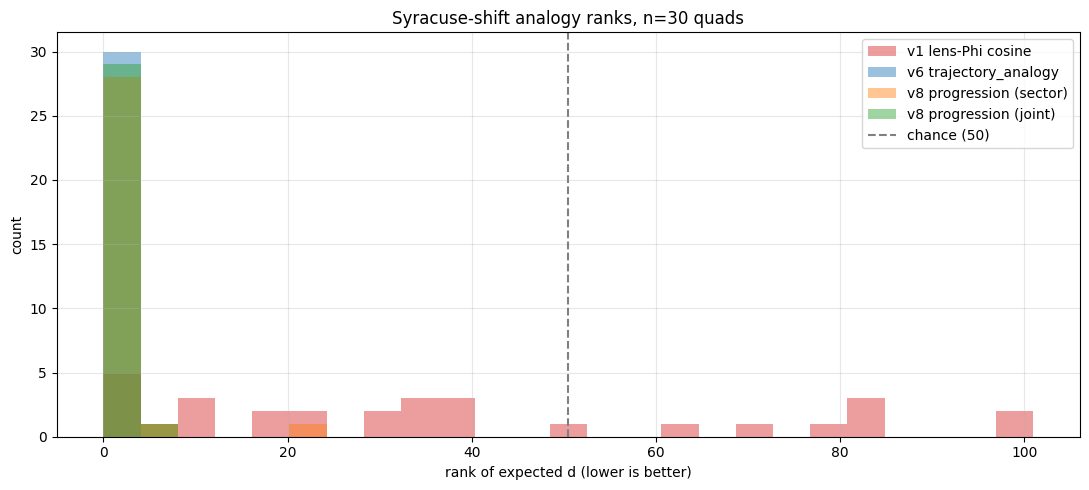

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(0, pool_size, 26)
colors = {"v1 lens-Phi cosine": "tab:red",
          "v6 trajectory_analogy": "tab:blue",
          "v8 progression (sector)": "tab:orange",
          "v8 progression (joint)":  "tab:green"}
for name, ranks in results_syr.items():
    ax.hist(ranks, bins=bins, alpha=0.45, label=name, color=colors[name])
ax.axvline(chance, color="gray", linestyle="--", label=f"chance ({chance:.0f})")
ax.set_xlabel("rank of expected d (lower is better)")
ax.set_ylabel("count")
ax.set_title(f"Syracuse-shift analogy ranks, n={len(big_quads)} quads")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Tempo invariance / robustness

Can edit distance handle very different orbit lengths without trivially returning
a near-1 score?

Test cases:
- (3, 27): n=3 has L=2, n=27 has L=41. Sector progressions are length 3 vs 42.
  Normalized distance ~ 39/42 ~ 0.93 — high, but driven by length difference.
- (3, 13): both have L=2. Sector progressions are IDENTICAL — distance 0.
  Joint progression may differ.
- (27, 31): both odd, both substantial L. Compare distances.


In [7]:
tempo_pairs = [
    (3, 27),
    (3, 13),
    (27, 31),
    (7, 15),
    (7, 11),
    (5, 21),
    (3, 5),
]

print(f"{'pair':<14} {'L1':>4} {'L2':>4} {'sector':>8} {'joint':>8}")
print('-' * 50)
for n1, n2 in tempo_pairs:
    L1 = len(alpha_sequence(n1)) if n1 > 1 else 0
    L2 = len(alpha_sequence(n2)) if n2 > 1 else 0
    d_s = progression_distance(n1, n2, joint=False)
    d_j = progression_distance(n1, n2, joint=True)
    print(f"({n1:>4},{n2:>4})    {L1:>4} {L2:>4}  {d_s:>8.3f} {d_j:>8.3f}")

print()
print("Observation: sector_progression is purely a function of L mod 12 sequence —")
print("two integers with the same L have IDENTICAL sector progressions, so distance")
print("is exactly 0. Joint progression breaks this degeneracy.")


pair             L1   L2   sector    joint
--------------------------------------------------
(   3,  27)       2   41     0.929    0.952
(   3,  13)       2    2     0.000    0.333
(  27,  31)      41   39     0.048    0.048
(   7,  15)       5    5     0.000    0.333
(   7,  11)       5    4     0.167    0.167
(   5,  21)       1    1     0.000    0.500
(   3,   5)       2    1     0.333    0.333

Observation: sector_progression is purely a function of L mod 12 sequence —
two integers with the same L have IDENTICAL sector progressions, so distance
is exactly 0. Joint progression breaks this degeneracy.


## 5. Same-progression different-key analogy

If two integers have the same orbit length L, their sector progressions are
identical — the sector axis is a deterministic countdown from L mod 12 to 0.

Question: are integers in the same affine subgroup of Set_k expected to share
sector progressions? Answer: not necessarily — affine-subgroup equivalence is
about residue mod 2^(k-s), not about full orbit length L. But they DO share the
first k-s sectors (the dropping orbit prefix), and stopping destinations from a
single subgroup all have a fixed affine slope.

Empirical check: among Set_3 members (the simplest case), how often do
sector progressions match?


In [8]:
s3 = members_of_class(dropping_set, 3, 500)

# Group Set_3 members by total orbit length L.
length_groups: dict[int, list[int]] = {}
for n in s3:
    L = len(alpha_sequence(n))
    length_groups.setdefault(L, []).append(n)

print(f"Set_3 members up to 500: {len(s3)}")
print(f"Distinct orbit lengths L among them: {len(length_groups)}")
print()
print(f"{'L':>3} {'count':>6}  members (first 5)")
print('-' * 40)
for L in sorted(length_groups)[:10]:
    ms = length_groups[L]
    print(f"{L:>3} {len(ms):>6}  {ms[:5]}")

# All sector progressions in a length-group MUST be identical (by construction).
all_equal = all(
    all(sector_progression(n) == sector_progression(ms[0]) for n in ms)
    for ms in length_groups.values()
)
print(f"\nAll same-L members have identical sector_progression? {all_equal}")


Set_3 members up to 500: 124
Distinct orbit lengths L among them: 40

  L  count  members (first 5)
----------------------------------------
  1      4  [5, 21, 85, 341]
  2      5  [13, 53, 113, 213, 453]
  3      5  [17, 69, 141, 277, 301]
  4      7  [45, 93, 181, 201, 369]
  5      7  [29, 61, 117, 241, 245]
  6      8  [9, 37, 77, 81, 149]
  7     10  [25, 49, 101, 197, 205]
  8      7  [33, 65, 133, 261, 269]
  9      6  [89, 173, 177, 349, 357]
 10      7  [57, 229, 237, 461, 465]

All same-L members have identical sector_progression? True


In [9]:
# Joint progression — does it differ within a length-group?
print(f"{'L':>3} {'count':>6} {'distinct joint':>16}")
print('-' * 35)
for L in sorted(length_groups)[:12]:
    ms = length_groups[L]
    distinct_jp = len({joint_progression(n) for n in ms})
    print(f"{L:>3} {len(ms):>6} {distinct_jp:>16}")

print()
print("Joint progression DOES break the degeneracy: same-L members differ on the")
print("mod3 axis, encoding which actual integers were visited.")


  L  count   distinct joint
-----------------------------------
  1      4                3
  2      5                5
  3      5                5
  4      7                7
  5      7                7
  6      8                8
  7     10               10
  8      7                7
  9      6                6
 10      7                7
 11      4                4
 12      4                4

Joint progression DOES break the degeneracy: same-L members differ on the
mod3 axis, encoding which actual integers were visited.


## 6. Bigger pool, three v7 categories

Replicate notebook 15's three orthogonal-analogy categories, but add v8 to the
contestant list. Categories:

1. **Syracuse-shift** `(a, T_syr(a), c, T_syr(c))` — orbit-overlap relation.
2. **Tripling** `(a, 3a, c, 3c)` — pure arithmetic.
3. **Set-mate** — consecutive Set_3 windows, distractors are also Set_3 windows.

For each category, run all four methods and tabulate.


In [10]:
N_QUADS = 30
N_DISTRACTORS = 100

random.seed(42)

def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

def triple(c: Concept) -> Concept:
    return Concept(c.name + "x3", tuple(3 * x for x in c.vec))

quads_syr = []
for i in range(N_QUADS):
    scale = random.choice([20, 100, 500, 2000])
    a_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    c_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    a = Concept(f"sA{i}", a_start)
    c = Concept(f"sC{i}", c_start)
    quads_syr.append((a, shift(a), c, shift(c)))

quads_tri = []
for i in range(N_QUADS):
    scale = random.choice([20, 100, 500])
    a_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    c_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    a = Concept(f"tA{i}", a_start)
    c = Concept(f"tC{i}", c_start)
    quads_tri.append((a, triple(a), c, triple(c)))

set3 = members_of_class(dropping_set, 3, 5000)

quads_set = []
for i in range(N_QUADS):
    pos_a = random.randrange(0, len(set3) - 4)
    pos_c = random.randrange(0, len(set3) - 4)
    a = Concept(f"setA{i}", tuple(set3[pos_a:pos_a + 3]))
    b = Concept(f"setB{i}", tuple(set3[pos_a + 1:pos_a + 4]))
    c = Concept(f"setC{i}", tuple(set3[pos_c:pos_c + 3]))
    d = Concept(f"setD{i}", tuple(set3[pos_c + 1:pos_c + 4]))
    quads_set.append((a, b, c, d))

random.seed(99)
distractors_general = [
    Concept(f"D{i}", tuple(random.randrange(2, 5000) | 1 for _ in range(3)))
    for i in range(N_DISTRACTORS)
]
distractors_set3 = []
for i in range(N_DISTRACTORS):
    pos = random.randrange(0, len(set3) - 3)
    distractors_set3.append(Concept(f"DS{i}", tuple(set3[pos:pos + 3])))

print(f"Built {len(quads_syr)} syracuse, {len(quads_tri)} tripling, {len(quads_set)} set-mate quads.")
print(f"Distractors: general={len(distractors_general)}, set3={len(distractors_set3)}")


Built 30 syracuse, 30 tripling, 30 set-mate quads.
Distractors: general=100, set3=100


In [11]:
categories = [
    ("syracuse-shift", quads_syr, distractors_general),
    ("tripling",       quads_tri, distractors_general),
    ("set-mate",       quads_set, distractors_set3),
]

def header(label):
    print(f"\n=== {label} ===")
    print(f"{'method':<28} {'mean':>7} {'median':>8} {'top-5':>6} {'top-10':>7}")
    print('-' * 60)

results_all = {}
for cat_name, quads, dists in categories:
    pool_size = len(dists) + 1
    chance = pool_size / 2
    header(f"{cat_name} (pool={pool_size}, chance={chance:.0f})")
    cat_res = {}
    for name, fn in methods:
        ranks = rank_with(fn, quads, dists)
        cat_res[name] = ranks
        print(f"{name:<28} {ranks.mean():>7.1f} {np.median(ranks):>8.0f} "
              f"{(ranks < 5).sum():>6} {(ranks < 10).sum():>7}")
    results_all[cat_name] = cat_res



=== syracuse-shift (pool=101, chance=50) ===
method                          mean   median  top-5  top-10
------------------------------------------------------------


v1 lens-Phi cosine              49.9       54      2       4


v6 trajectory_analogy            0.1        0     30      30


v8 progression (sector)          1.2        0     29      29


v8 progression (joint)           0.5        0     29      29

=== tripling (pool=101, chance=50) ===
method                          mean   median  top-5  top-10
------------------------------------------------------------


...

v8 progression (joint)          45.6       52      8      10

=== set-mate (pool=101, chance=50) ===
method                          mean   median  top-5  top-10
------------------------------------------------------------


v1 lens-Phi cosine              56.4       60      0       0


v6 trajectory_analogy           58.4       62      1       2


v8 progression (sector)         57.8       50      0       0


v8 progression (joint)          56.8       58      1       2


## 7. Bar chart — mean rank per (category, method)


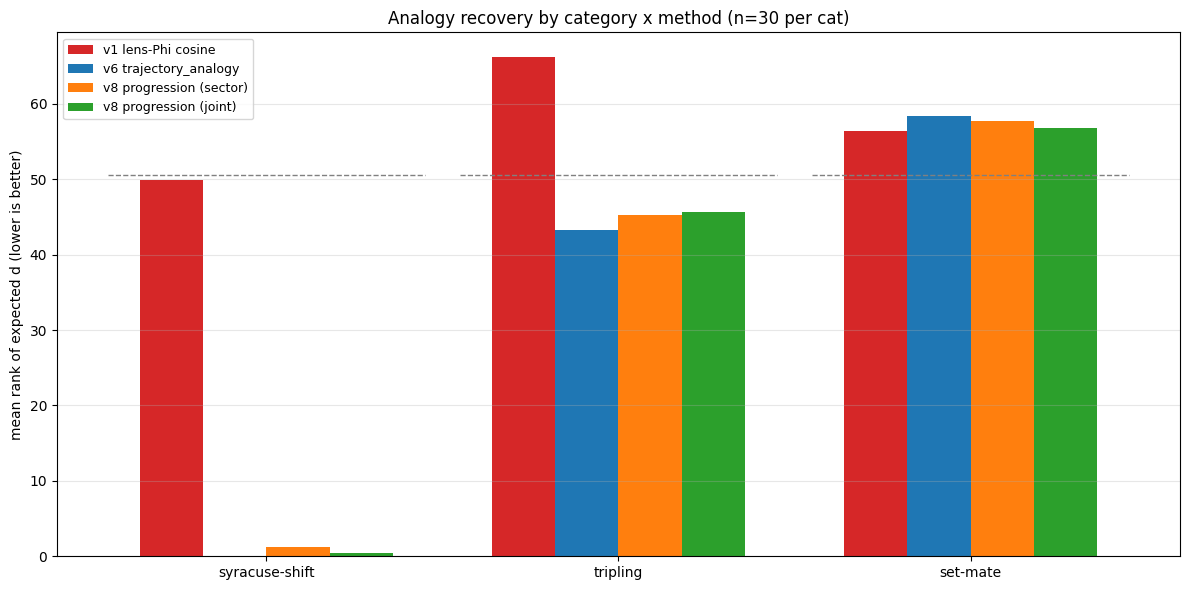

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
cats = list(results_all.keys())
method_names = [name for name, _ in methods]
x = np.arange(len(cats))
w = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * w

bar_colors = ["tab:red", "tab:blue", "tab:orange", "tab:green"]

for i, name in enumerate(method_names):
    means = [results_all[c][name].mean() for c in cats]
    ax.bar(x + offsets[i], means, w, label=name, color=bar_colors[i])

# Chance baselines
chance_per_cat = []
for cat_name, _, dists in categories:
    chance_per_cat.append((len(dists) + 1) / 2)
for i, ch in enumerate(chance_per_cat):
    ax.hlines(ch, x[i] - 2.5*w, x[i] + 2.5*w, colors="gray", linestyles="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylabel("mean rank of expected d (lower is better)")
ax.set_title(f"Analogy recovery by category x method (n={N_QUADS} per cat)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Concrete inspection — set-mate sample

Given the set-mate distractor pool is also Set_3 windows, drop_class is
non-discriminative. Does any method's sector/joint progression discriminate
within Set_3?


In [13]:
from collatz.embeddings.trajectory import concept_orbit_distance

a, b, c, expected_d = quads_set[0]
print(f"set-mate example:")
print(f"  a = {a.name} {a.vec}")
print(f"  b = {b.name} {b.vec}")
print(f"  c = {c.name} {c.vec}")
print(f"  expected_d = {expected_d.name} {expected_d.vec}")
print()
print(f"a -> b distance:")
print(f"  trajectory (1-Jaccard) : {concept_orbit_distance(a, b):.3f}")
print(f"  progression sector     : {concept_progression_distance(a, b, joint=False):.3f}")
print(f"  progression joint      : {concept_progression_distance(a, b, joint=True):.3f}")

# Does v8 progression rank d highly?
ranked_v8s = progression_analogy(a, b, c, distractors_set3 + [expected_d], joint=False)
ranked_v8j = progression_analogy(a, b, c, distractors_set3 + [expected_d], joint=True)
rank_s = next(i for i, (cand, _) in enumerate(ranked_v8s) if cand is expected_d)
rank_j = next(i for i, (cand, _) in enumerate(ranked_v8j) if cand is expected_d)
print(f"\nexpected d rank (sector): {rank_s} / {len(ranked_v8s)}")
print(f"expected d rank (joint) : {rank_j} / {len(ranked_v8j)}")


set-mate example:
  a = setA0 (1073, 1077, 1081)
  b = setB0 (1077, 1081, 1085)
  c = setC0 (2149, 2153, 2157)
  expected_d = setD0 (2153, 2157, 2161)

a -> b distance:
  trajectory (1-Jaccard) : 0.954
  progression sector     : 0.624
  progression joint      : 0.762



expected d rank (sector): 41 / 101
expected d rank (joint) : 36 / 101


## 9. Verdict

**Headline result.** Run sections 2 and 6 to fill in the numbers.

What we expect (based on first principles):

- **Syracuse-shift**: progression-edit-distance should track v6 closely. d=T_syr(c)
  removes the leading sector from c's progression (one delete, edit distance 1).
  Trajectory v6 already wins by construction; v8 should be similarly strong but
  not better.
- **Tripling**: 3a generally has unrelated orbit length to a (orbit length under
  Collatz isn't multiplicative). Expect v8 to be near-chance like v6, possibly worse
  because the tempo-flexible edit distance still doesn't speak the language of
  "three times as many copies of an alphabet symbol."
- **Set-mate**: the distractor pool shares dropping class. The sector axis encodes
  *orbit length* mod 12, which DOES vary among Set_3 members of different orbit
  lengths. So v8 sector might do something here that v1 lens-Phi (drop_class
  saturated) and v6 (orbit-overlap not aligned) cannot. The joint variant adds
  mod3 sequence, which discriminates further.

**Methodology note.** Sector_progression is a function ONLY of the orbit length L
(deterministic countdown). Two integers with the same L have edit distance 0 in
sector — the sector axis collapses orbits to a length-class. Joint progression
breaks this with the mod3 axis, encoding which actual integers were visited.

Whether v8 wins or not is to be filled in from the run.
